# SVM In-Class Exercises

In-class exercises to accompnay the video lectures.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Problem 1.  Margin 

For the points below with binary labels:
*  Create a scatter plot of the points with different markers for the two classes
*  Find the weight and bias of the classifier that separates the two classes
*  Compute the distance to the classifier boundary for the points
*  Find the margin

margin:  0.23426064283290912


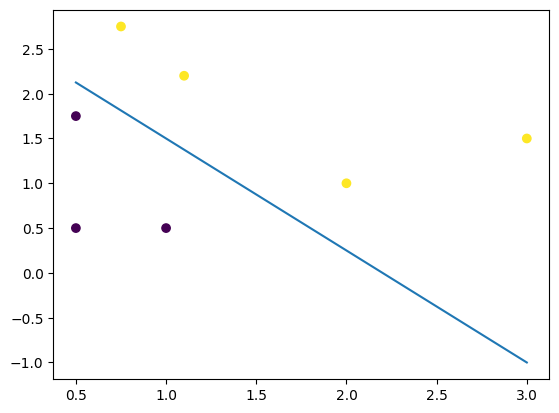

In [34]:
X = np.array([[0.5,0.5], [1,0.5],[0.5,1.75], [0.75,2.75], [1.1,2.2], [2,1], [3,1.5]])
y = -np.array([1,1,1,-1,-1,-1,-1])

w = np.array([1, 0.8])
p = np.array([1, 1.5])
b = - np.dot(w,p)

f = lambda x: np.dot(w,x) + b
sdist = lambda x: f(x) / np.sqrt(np.dot(w,w))

x1 = np.linspace(0.5,3,2)
x2 = (np.dot(p,w) - x1 * w[0]) / w[1]

sdist_vec = np.zeros(X.shape[0])
for ii in np.arange(X.shape[0]):
    sdist_vec[ii] = sdist(X[ii,:])

d = sdist_vec * y
print("margin: ", np.min(d))

plt.scatter(X[:,0], X[:,1], c=y)
plt.plot(x1, x2)
plt.show()


## Problem 2.  Minimizing the Hinge Loss

For the data below, first create a scatter plot of the points with different markers for the two classes.  You should see that the data is not linearly separable.

Then, consider a set of classifiers:

    yhat = sign(z),   z = w.dot(x)+b
   
Use the the `w` below, plot the hinge loss as a function of the bias `b` where the hinge loss is: 

    J  = sum( maximum(0, 1-ypm*z) )

Here `ypm=2*y-1` so that it is a value +1 or -1.  Find the `b` that minimizes the hinge loss and plot the boundary of the classifier.

In [35]:
X = np.array([[0.5,0.5], [1,0.5],[0.5,1.75], [2,2], [0.75,0.75], [0.75,2.75], [1.1,2.2], [2,1], [3,1.5]])
y = np.array([1,1,1,1,0,0,0,0,0])

w = np.array([1.5, 1])
w = w / np.linalg.norm(w)

In [36]:
ypm = 2*y-1
print(ypm)

[ 1  1  1  1 -1 -1 -1 -1 -1]


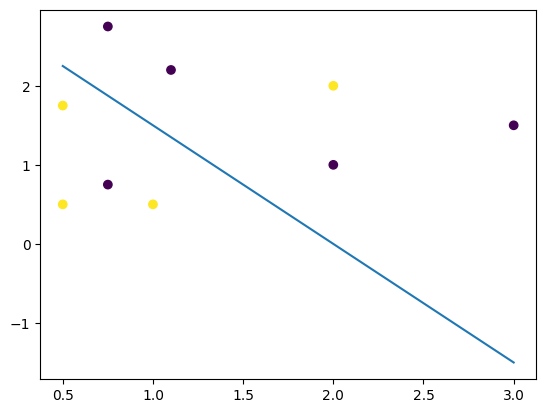

In [47]:
p = np.array([1, 1.5])
b = - np.dot(w,p)

f = lambda x: np.dot(w,x) + b

x1 = np.linspace(0.5,3,2)
x2 = (np.dot(p,w) - x1 * w[0]) / w[1]


plt.scatter(X[:,0], X[:,1], c=ypm)
plt.plot(x1, x2)
plt.show()

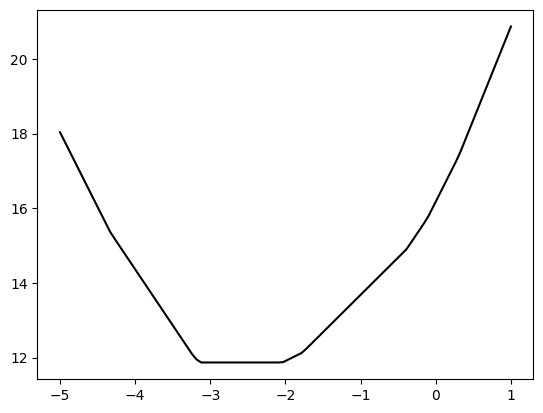

In [54]:
f = lambda x, w, b: np.dot(w,x) + b

def hingeloss(b):
    J = 0
    for ii in np.arange(X.shape[0]):
        J += np.maximum(0, 1-ypm[ii]*f(X[ii,:], w, b))
    return J

bvec = np.linspace(-5,1,100)
Jvec = [hingeloss(b) for b in bvec]
plt.plot(bvec, Jvec, 'k-')
plt.show()